In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
def add_technical_indicators(df):
    """Add RSI, MACD, Bollinger Bands, ATR, and moving averages."""
    close = df['Close']
    high = df['High']
    low = df['Low']
    
    # Moving averages
    df['SMA_7'] = close.rolling(7).mean()
    df['SMA_21'] = close.rolling(21).mean()
    
    # RSI (14-day)
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_signal'] = df['MACD'].ewm(span=9).mean()
    
    # Bollinger Bands (% position within band)
    sma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    df['BB_pct'] = (close - (sma20 - 2*std20)) / ((sma20 + 2*std20) - (sma20 - 2*std20) + 1e-10)
    
    # ATR (14-day) — normalized by close
    tr = pd.concat([high - low, (high - close.shift()).abs(), (low - close.shift()).abs()], axis=1).max(axis=1)
    df['ATR_pct'] = tr.rolling(14).mean() / close
    
    # Volume change ratio
    df['Vol_ratio'] = df['Volume'] / df['Volume'].rolling(14).mean()
    
    # Price returns
    df['Returns_1d'] = close.pct_change()
    df['Returns_5d'] = close.pct_change(5)
    
    return df

FEATURE_COLS = ['Close', 'Open', 'High', 'Low', 'Volume',
                'SMA_7', 'SMA_21', 'RSI', 'MACD', 'MACD_signal',
                'BB_pct', 'ATR_pct', 'Vol_ratio', 'Returns_1d', 'Returns_5d']



def get_bitcoin_data():
    btc = pd.read_csv('bitcoin_2023-03-09_2026-03-08.csv')
    # CSV is newest-first — reverse to chronological order (oldest first)
    btc = btc.iloc[::-1].reset_index(drop=True)
    btc = add_technical_indicators(btc)
    btc = btc.dropna().reset_index(drop=True)
    
    data = btc[FEATURE_COLS].values
    close_prices = btc['Close'].values  # keep raw close for later
    return data, btc, close_prices

def create_sequences(data, close_prices, sequence_length=60):
    """Target = next-day return (pct change of close), NOT absolute price."""
    X, y, y_close = [], [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, :])
        # Target: daily return = (close[i] - close[i-1]) / close[i-1]
        ret = (close_prices[i] - close_prices[i-1]) / close_prices[i-1]
        y.append(ret)
        y_close.append(close_prices[i])  # store actual close for backtesting
    return np.array(X), np.array(y), np.array(y_close)

In [295]:
class BitcoinLSTM(nn.Module):
    def __init__(self, input_dim=15, hidden_dim=64, num_layers=2, dropout=0.2):
        super(BitcoinLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = self.dropout(out[:, -1, :])
        return self.fc(last)  # single output: predicted return

In [296]:
criterion = nn.MSELoss()

In [297]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on device: {device}")

sequence_length = 60
raw_data, raw_df, close_prices = get_bitcoin_data()
X, y, y_close = create_sequences(raw_data, close_prices, sequence_length)
print(f"Total sequences: {X.shape[0]}, Features per timestep: {X.shape[2]}")
print(f"Target (daily return) — mean: {y.mean()*100:.3f}%, std: {y.std()*100:.3f}%")

Training on device: mps
Total sequences: 1015, Features per timestep: 15
Target (daily return) — mean: 0.121%, std: 2.473%


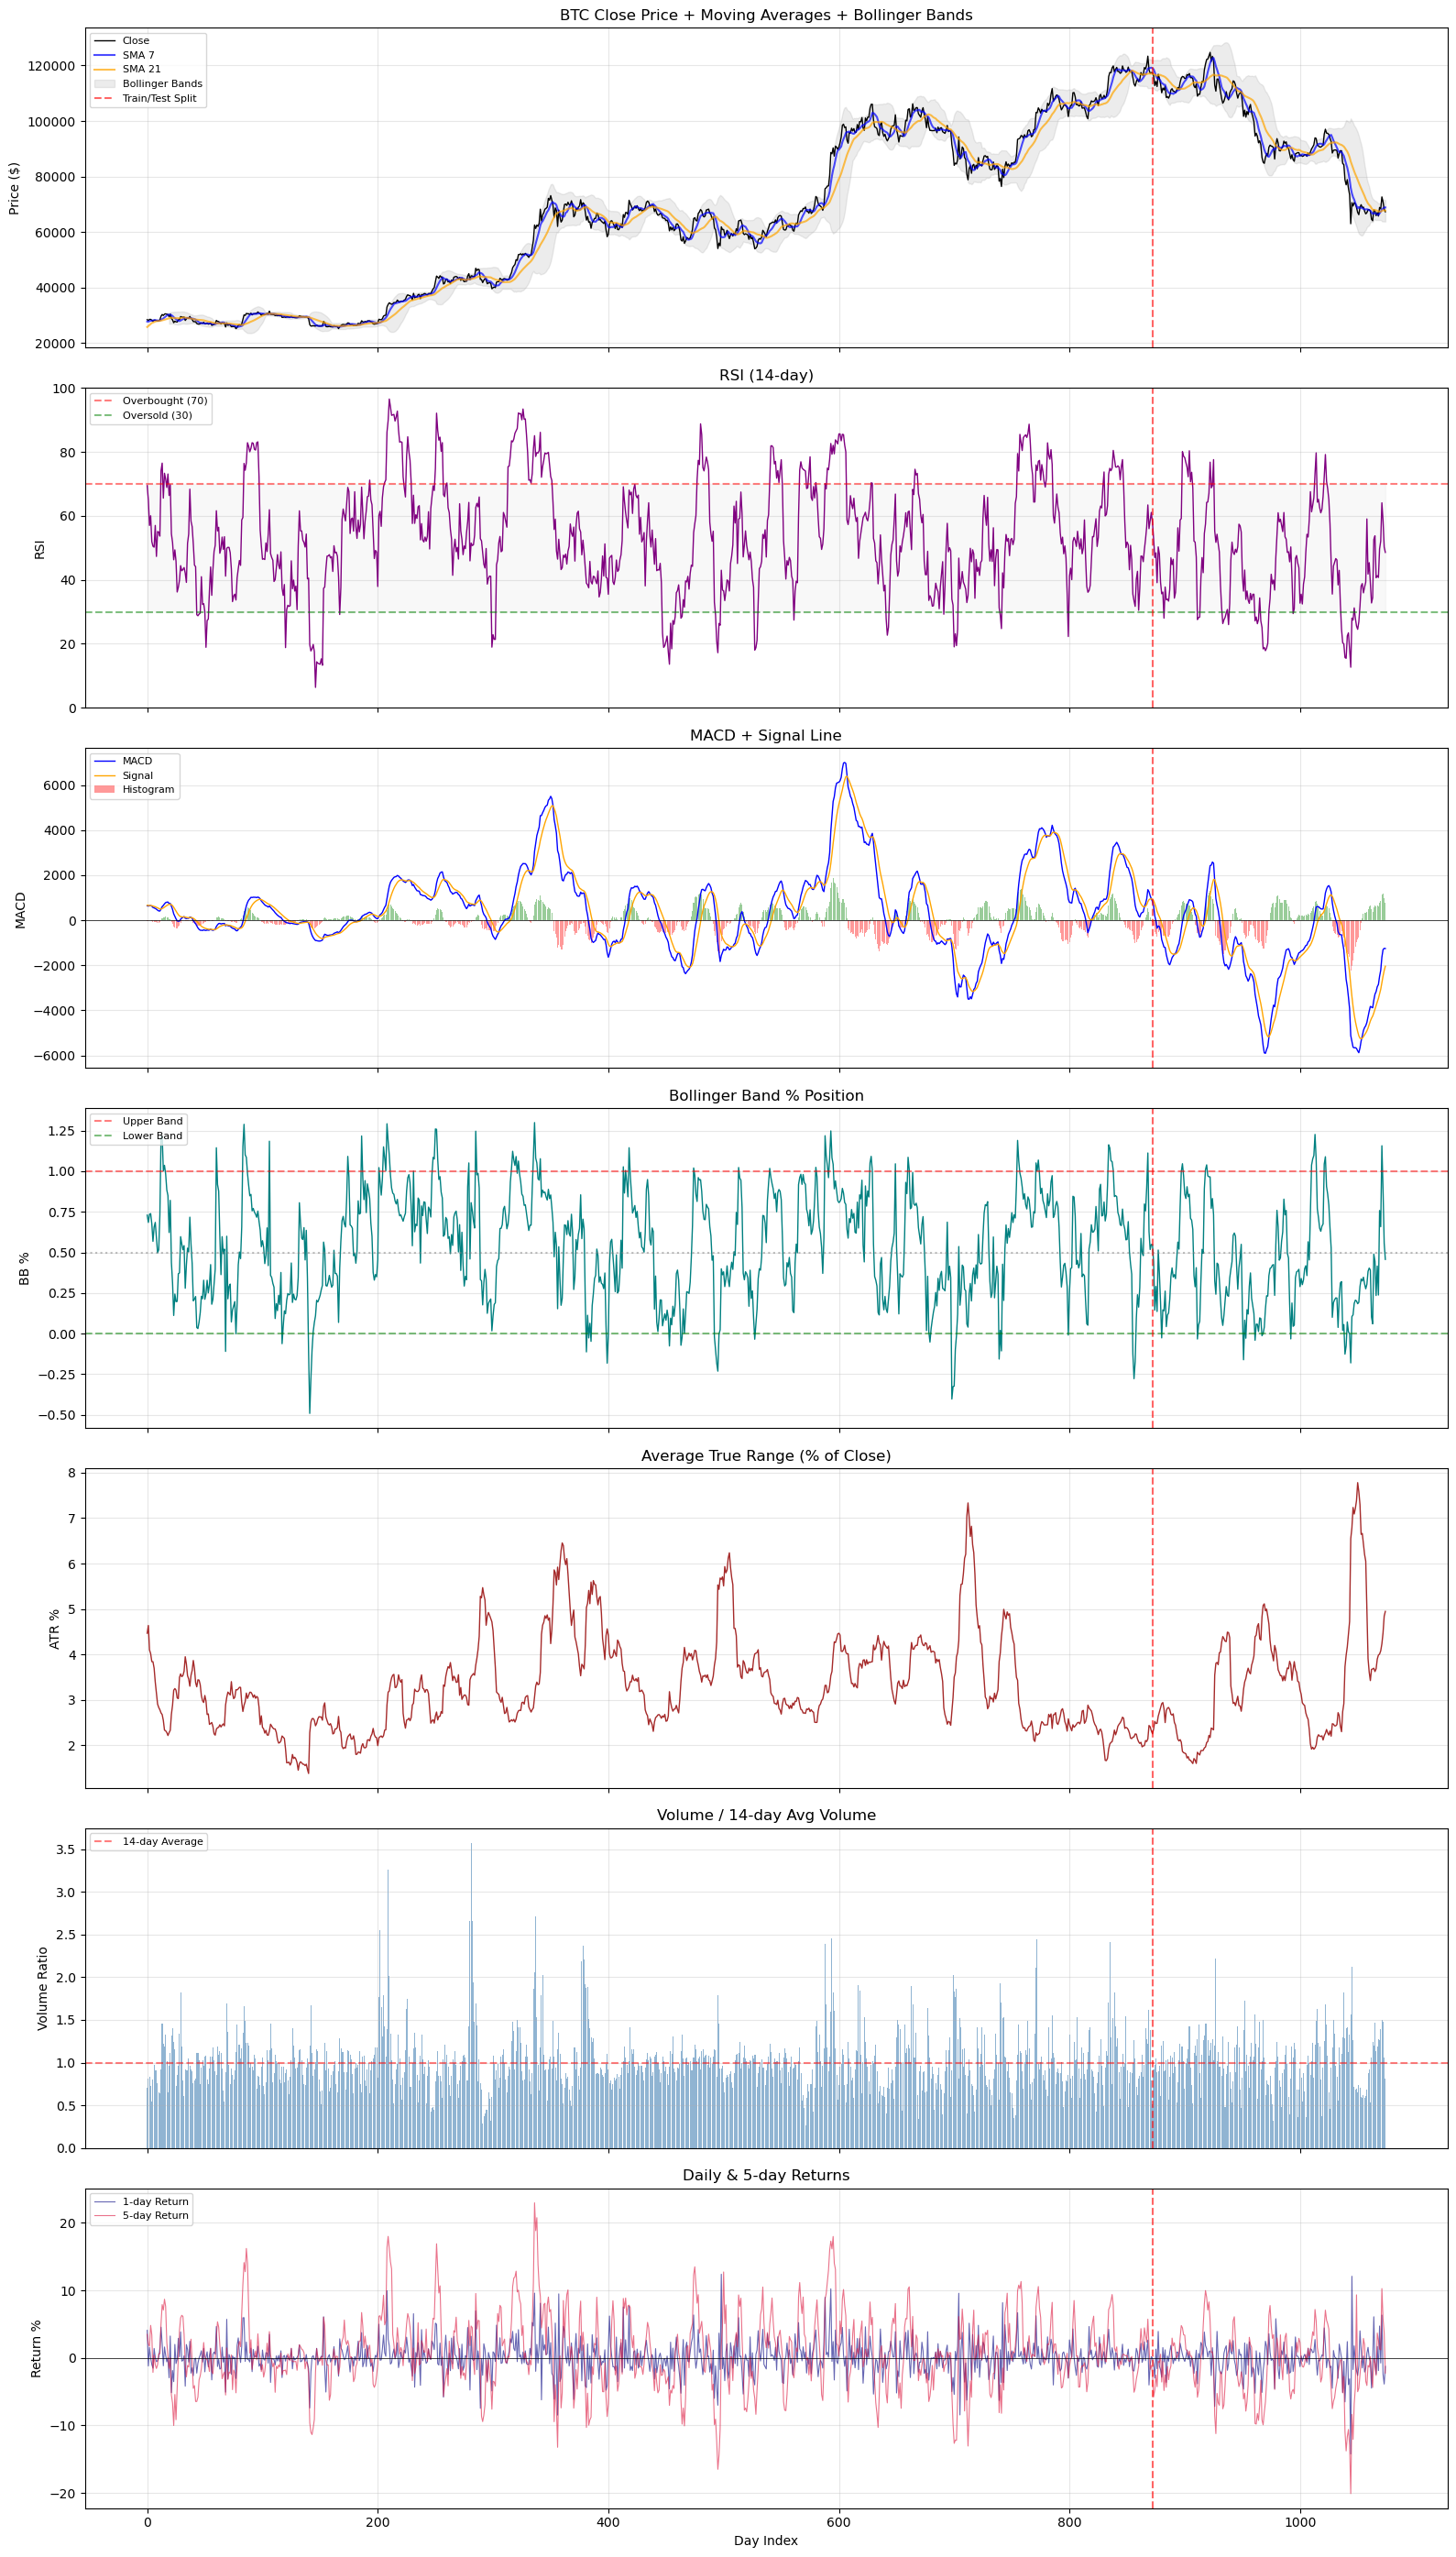

In [ ]:
import matplotlib.pyplot as plt

df = raw_df.copy()

fig, axes = plt.subplots(7, 1, figsize=(16, 28), sharex=True)

# Price + SMA 7/21 + Bollinger Bands
ax = axes[0]
sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
ax.plot(df['Close'], label='Close', color='black', linewidth=1)
ax.plot(df['SMA_7'], label='SMA 7', color='blue', alpha=0.7)
ax.plot(df['SMA_21'], label='SMA 21', color='orange', alpha=0.7)
ax.fill_between(df.index, sma20 - 2*std20, sma20 + 2*std20, alpha=0.15, color='gray', label='Bollinger Bands')
ax.axvline(x=split + sequence_length, color='red', linestyle='--', alpha=0.6, label='Train/Test Split')
ax.set_ylabel('Price ($)')
ax.set_title('BTC Close Price + Moving Averages + Bollinger Bands')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# RSI
ax = axes[1]
ax.plot(df['RSI'], color='purple', linewidth=1)
ax.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax.axvline(x=split + sequence_length, color='red', linestyle='--', alpha=0.6)
ax.fill_between(df.index, 30, 70, alpha=0.05, color='gray')
ax.set_ylabel('RSI')
ax.set_title('RSI (14-day)')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# MACD + Signal
ax = axes[2]
ax.plot(df['MACD'], label='MACD', color='blue', linewidth=1)
ax.plot(df['MACD_signal'], label='Signal', color='orange', linewidth=1)
macd_hist = df['MACD'] - df['MACD_signal']
colors = ['green' if v >= 0 else 'red' for v in macd_hist]
ax.bar(df.index, macd_hist, color=colors, alpha=0.4, label='Histogram')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(x=split + sequence_length, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('MACD')
ax.set_title('MACD + Signal Line')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# Bollinger Band %
ax = axes[3]
ax.plot(df['BB_pct'], color='teal', linewidth=1)
ax.axhline(1, color='red', linestyle='--', alpha=0.5, label='Upper Band')
ax.axhline(0, color='green', linestyle='--', alpha=0.5, label='Lower Band')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=split + sequence_length, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('BB %')
ax.set_title('Bollinger Band % Position')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# ATR %
ax = axes[4]
ax.plot(df['ATR_pct'] * 100, color='brown', linewidth=1)
ax.axvline(x=split + sequence_length, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('ATR %')
ax.set_title('Average True Range (% of Close)')
ax.grid(alpha=0.3)

# Volume Ratio
ax = axes[5]
ax.bar(df.index, df['Vol_ratio'], color='steelblue', alpha=0.6)
ax.axhline(1, color='red', linestyle='--', alpha=0.5, label='14-day Average')
ax.axvline(x=split + sequence_length, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('Volume Ratio')
ax.set_title('Volume / 14-day Avg Volume')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# Returns (1d and 5d)
ax = axes[6]
ax.plot(df['Returns_1d'] * 100, label='1-day Return', color='navy', alpha=0.6, linewidth=0.8)
ax.plot(df['Returns_5d'] * 100, label='5-day Return', color='crimson', alpha=0.6, linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(x=split + sequence_length, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('Return %')
ax.set_title('Daily & 5-day Returns')
ax.set_xlabel('Day Index')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [298]:
# Split into Train/Test (80/20)
split = int(len(X) * 0.8)
X_train_raw, X_test_raw = X[:split], X[split:]
y_train_raw, y_test_raw = y[:split], y[split:]
y_close_test = y_close[split:]  # actual close prices for backtesting

# Fit scaler on TRAINING features only (no leakage)
num_features = X_train_raw.shape[2]
scaler = MinMaxScaler(feature_range=(0, 1))
train_flat = X_train_raw.reshape(-1, num_features)
scaler.fit(train_flat)

X_train_scaled = scaler.transform(X_train_raw.reshape(-1, num_features)).reshape(X_train_raw.shape)
X_test_scaled = scaler.transform(X_test_raw.reshape(-1, num_features)).reshape(X_test_raw.shape)

# Target is daily return — already small numbers, no scaling needed
y_train_final = y_train_raw.reshape(-1, 1)
y_test_final = y_test_raw.reshape(-1, 1)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Train returns — mean: {y_train_final.mean()*100:.3f}%, std: {y_train_final.std()*100:.3f}%")

Train: (812, 60, 15), Test: (203, 60, 15)
Train returns — mean: 0.212%, std: 2.457%


In [299]:
X_train = torch.from_numpy(X_train_scaled).float()
y_train = torch.from_numpy(y_train_final).float()
X_test = torch.from_numpy(X_test_scaled).float()
y_test = torch.from_numpy(y_test_final).float()

model = BitcoinLSTM(input_dim=X_train.shape[2]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=50
)

epochs = 1500
loss_history = []
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 150

print("Starting Training...")
X_train_d, y_train_d = X_train.to(device), y_train.to(device)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train_d)
    loss = criterion(pred, y_train_d)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step(loss)
    
    loss_val = loss.item()
    loss_history.append(loss_val)
    
    if loss_val < best_loss - 1e-8:
        best_loss = loss_val
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    
    if patience_counter >= early_stop_patience:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(best_state)
        break
    
    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss_val:.8f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')

print(f"Best training loss: {best_loss:.8f}")

Starting Training...
Epoch [50/1500], Loss: 0.00079051, LR: 0.001000
Epoch [100/1500], Loss: 0.00068322, LR: 0.001000
Epoch [150/1500], Loss: 0.00062923, LR: 0.001000
Epoch [200/1500], Loss: 0.00061343, LR: 0.001000
Epoch [250/1500], Loss: 0.00060414, LR: 0.001000
Epoch [300/1500], Loss: 0.00058751, LR: 0.001000
Epoch [350/1500], Loss: 0.00056695, LR: 0.001000
Epoch [400/1500], Loss: 0.00056352, LR: 0.001000
Epoch [450/1500], Loss: 0.00052621, LR: 0.001000
Epoch [500/1500], Loss: 0.00052718, LR: 0.001000
Epoch [550/1500], Loss: 0.00048723, LR: 0.001000
Epoch [600/1500], Loss: 0.00044388, LR: 0.001000
Epoch [650/1500], Loss: 0.00038808, LR: 0.001000
Epoch [700/1500], Loss: 0.00032660, LR: 0.001000
Epoch [750/1500], Loss: 0.00026807, LR: 0.001000
Epoch [800/1500], Loss: 0.00024683, LR: 0.001000
Epoch [850/1500], Loss: 0.00023792, LR: 0.001000
Epoch [900/1500], Loss: 0.00017483, LR: 0.001000
Epoch [950/1500], Loss: 0.00017011, LR: 0.001000
Epoch [1000/1500], Loss: 0.00015898, LR: 0.001000

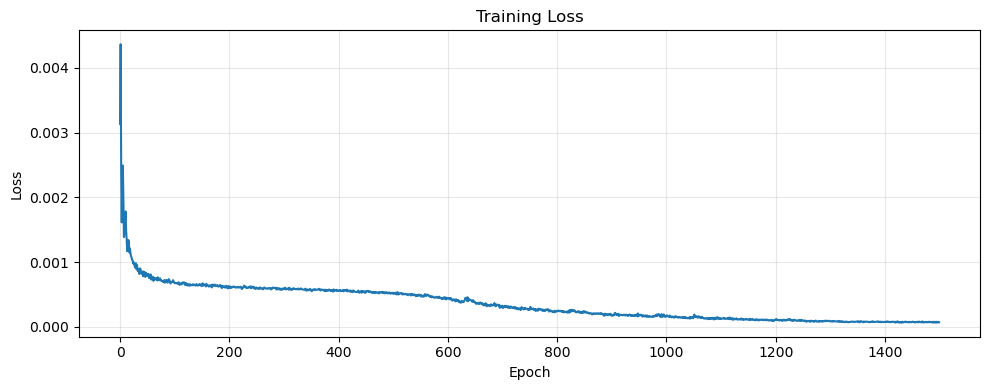

In [301]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [302]:
model.eval()
with torch.no_grad():
    X_test_d = X_test.to(device)
    pred_returns = model(X_test_d).cpu().numpy().flatten()
    actual_returns = y_test.numpy().flatten()

real_actuals = y_close_test  # actual close prices for backtesting

print(f"Predicted returns — mean: {pred_returns.mean()*100:.4f}%, std: {pred_returns.std()*100:.4f}%")
print(f"Actual returns    — mean: {actual_returns.mean()*100:.4f}%, std: {actual_returns.std()*100:.4f}%")

# --- SIGNAL GENERATION ---
signals = []
threshold = 0.003  # 0.3% — lower threshold since returns are small

for i in range(1, len(pred_returns)):
    if pred_returns[i] > threshold:
        signals.append("BUY")
    elif pred_returns[i] < -threshold:
        signals.append("SELL")
    else:
        signals.append("HOLD")

from collections import Counter
print(f"\nSignal distribution: {Counter(signals)}")
print(f"Threshold: {threshold*100:.1f}%")

# Simple fixed position sizing
position_sizes = []
for i in range(len(signals)):
    if signals[i] in ("BUY", "SELL"):
        position_sizes.append(0.5)  # 50% of available capital
    else:
        position_sizes.append(0)

Predicted returns — mean: -2.5324%, std: 1.6764%
Actual returns    — mean: -0.2424%, std: 2.5041%

Signal distribution: Counter({'SELL': 181, 'BUY': 14, 'HOLD': 7})
Threshold: 0.3%


Initial $10,000.00  →  Final $8,939.44  |  Strategy Return: -10.61%
Buy-and-Hold Return: -42.13%
Trades: 13 buys, 1 sells, 1 stops, 0 take-profits


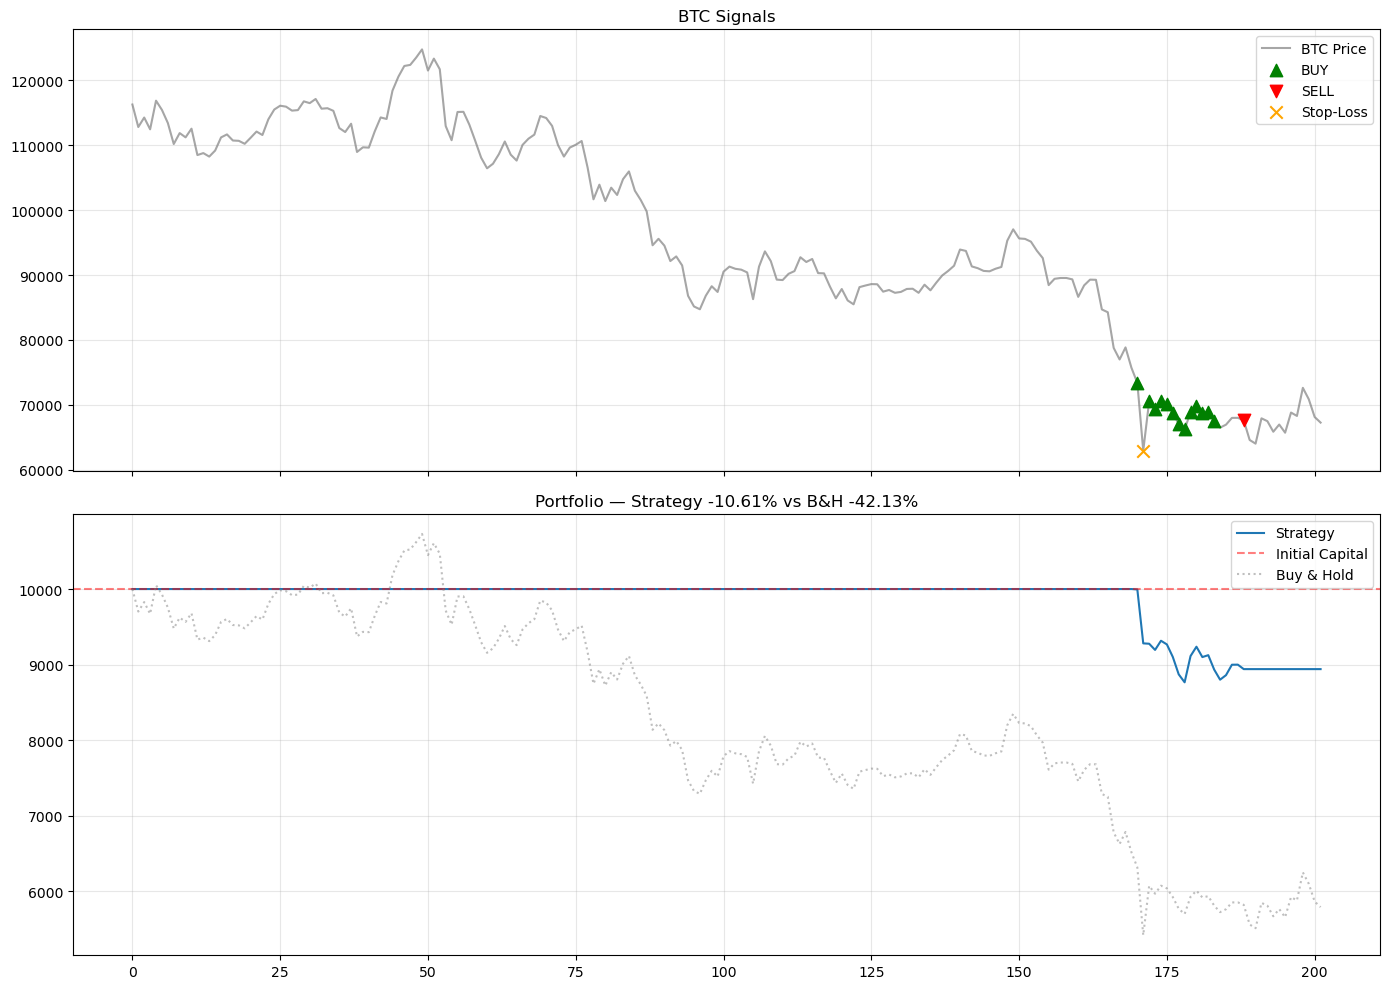

In [ ]:
import numpy as np, matplotlib.pyplot as plt

init = 10000.
fee = 0.001
stop = 0.10      # 10% stop-loss
take_profit = 0.08  # 8% take-profit

# real_actuals is now y_close_test (actual close prices, 1D array)
# signals has len = len(real_actuals) - 1 (starts from index 1)
prices = real_actuals[1:]  # align with signals
cash, btc, entry = init, 0., 0.
hist = []; bi = []; bp = []; si = []; sp = []; sti = []; stp = []; tpi = []; tpp = []

for i, (sig, p) in enumerate(zip(signals, prices)):
    if btc and p <= entry * (1 - stop):
        cash += btc * p * (1 - fee); btc = entry = 0.
        sti.append(i); stp.append(p)

    elif btc and p >= entry * (1 + take_profit):
        cash += btc * p * (1 - fee); btc = entry = 0.
        tpi.append(i); tpp.append(p)
    
    elif sig == "BUY" and cash > 0:
        amt = cash * position_sizes[i]
        btc += (amt * (1 - fee)) / p
        cash -= amt
        entry = p
        bi.append(i); bp.append(p)

    elif sig == "SELL" and btc > 0:
        cash += btc * p * (1 - fee); btc = entry = 0.
        si.append(i); sp.append(p)
    
    hist.append(cash + btc * p)

if btc: cash += btc * prices[-1] * (1 - fee)
ret = (cash - init) / init * 100
bh_ret = (prices[-1] - prices[0]) / prices[0] * 100

print(f"Initial ${init:,.2f}  →  Final ${cash:,.2f}  |  Strategy Return: {ret:.2f}%")
print(f"Buy-and-Hold Return: {bh_ret:.2f}%")
print(f"Trades: {len(bi)} buys, {len(si)} sells, {len(sti)} stops, {len(tpi)} take-profits")

fig, (a, b) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
a.plot(prices, c='gray', alpha=0.7, label='BTC Price')
a.scatter(bi, bp, c='green', marker='^', s=80, label='BUY', zorder=5)
a.scatter(si, sp, c='red', marker='v', s=80, label='SELL', zorder=5)
if sti: a.scatter(sti, stp, c='orange', marker='x', s=80, label='Stop-Loss', zorder=5)
if tpi: a.scatter(tpi, tpp, c='blue', marker='D', s=60, label='Take-Profit', zorder=5)
a.set_title("BTC Signals"); a.legend(); a.grid(alpha=0.3)

b.plot(hist, label='Strategy')
b.axhline(init, c='red', ls='--', alpha=0.5, label='Initial Capital')
bh_line = [init * (p / prices[0]) for p in prices[:len(hist)]]
b.plot(bh_line, c='gray', alpha=0.5, ls=':', label='Buy & Hold')
b.set_title(f"Portfolio — Strategy {ret:.2f}% vs B&H {bh_ret:.2f}%")
b.legend(); b.grid(alpha=0.3)

plt.tight_layout(); plt.show()